In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nc_files = sorted(glob.glob("C:/Users\locfa_v05v5qi/Documents/escadas_termohalinas/raw/Dataset/**/*.nc", recursive=True))

In [3]:
def subset_region(ds):
    # Ajustar longitudes se estiverem em 0–360
    if ds.lon.max() > 180:
        ds = ds.assign_coords(
            lon=((ds.lon + 180) % 360) - 180
        )

    # Criar máscara apenas para a dimensão n (perfis)
    mask = (
        (ds.lat <= 10) & (ds.lat >= -60) &
        (ds.lon >= -60) & (ds.lon <= -10)
    )

    if "Nobs" in ds.dims:
        ds = ds.isel(Nobs=mask)

    return ds
    
def check_staircase_exists(ml_h, gl_h): #verifica se os valores são fisicamente válidos (n só se existem)

    valid_ml = np.sum(~np.isnan(ml_h) & (ml_h > 0))
    valid_gl = np.sum(~np.isnan(gl_h) & (gl_h > 0))

    return (valid_ml >= 1) and (valid_gl >= 1)
    
def detect_staircases(ds):

    profile_dim = ds.lat.dims[0]
    n_profiles = ds.sizes[profile_dim] #p n ter problema d confundir "n" e "Nobs"

    staircase_sf = np.zeros(n_profiles, dtype=bool)
    staircase_dc = np.zeros(n_profiles, dtype=bool)

    for i in range(n_profiles):

        # SALT FINGER
        ml_mask_sf = ds.mask_ml_sf_layer.isel({profile_dim: i}) > 0
        gl_mask_sf = ds.mask_gl_sf_layer.isel({profile_dim: i}) > 0

        ml_h_sf = ds.ml_h.isel({profile_dim: i}).values[ml_mask_sf.values] #pega os valores onde ml_mask_sf é True 
        gl_h_sf = ds.gl_h.isel({profile_dim: i}).values[gl_mask_sf.values]

        if len(ml_h_sf) > 0 and len(gl_h_sf) > 0:
            staircase_sf[i] = check_staircase_exists(
                ml_h_sf, gl_h_sf
            )

        # DIFFUSIVE CONVECTION
        ml_mask_dc = ds.mask_ml_dc_layer.isel({profile_dim: i}) > 0
        gl_mask_dc = ds.mask_gl_dc_layer.isel({profile_dim: i}) > 0

        ml_h_dc = ds.ml_h.isel({profile_dim: i}).values[ml_mask_dc.values]
        gl_h_dc = ds.gl_h.isel({profile_dim: i}).values[gl_mask_dc.values]

        if len(ml_h_dc) > 0 and len(gl_h_dc) > 0:
            staircase_dc[i] = check_staircase_exists(
                ml_h_dc, gl_h_dc
            )

    ds["staircase_sf"] = (profile_dim, staircase_sf)
    ds["staircase_dc"] = (profile_dim, staircase_dc)


In [4]:
#teste
df_misto = {
    "lat": [],
    "lon": [],
    "depth": [],
    "regime": []   # ← faltava isso
}

df_puro = {
    "lat": [],
    "lon": [],
    "depth": [],
    "regime": []   # ← já deixa pronto
}

for fname in nc_files:
    try:
        ds = xr.open_dataset(fname)
        ds = subset_region(ds)
        nobs = ds.sizes.get("Nobs", 0)
        
        if nobs == 0:
            ds.close()
            continue

        for i in range(nobs):
            lat = float(ds.lat[i])
            lon = float(ds.lon[i])
            
            sf_mask = ds.mask_ml_sf_layer[i, :].values
            dc_mask = ds.mask_ml_dc_layer[i, :].values

            idx_sf = np.where(sf_mask > 0)[0]
            idx_dc = np.where(dc_mask > 0)[0]

            # ======================
            # PERFIL MISTO
            # ======================
            if len(idx_sf) > 0 and len(idx_dc) > 0:

                layers = []

                for j in idx_sf:
                    depth = float(ds.ml_p[i, j])
                    layers.append((depth, "SF"))

                for j in idx_dc:
                    depth = float(ds.ml_p[i, j])
                    layers.append((depth, "DC"))

                layers_sorted = sorted(layers, key=lambda x: x[0])

                for depth, regime in layers_sorted:
                    df_misto["lat"].append(lat)
                    df_misto["lon"].append(lon)
                    df_misto["depth"].append(depth)
                    df_misto["regime"].append(regime)

            # ======================
            # PERFIS PUROS
            # ======================
            elif len(idx_sf) > 0 and len(idx_dc) == 0:

                for j in idx_sf:
                    depth = float(ds.ml_p[i, j])
                    df_puro["lat"].append(lat)
                    df_puro["lon"].append(lon)
                    df_puro["depth"].append(depth)
                    df_puro["regime"].append("SF")

            elif len(idx_dc) > 0 and len(idx_sf) == 0:

                for j in idx_dc:
                    depth = float(ds.ml_p[i, j])
                    df_puro["lat"].append(lat)
                    df_puro["lon"].append(lon)
                    df_puro["depth"].append(depth)
                    df_puro["regime"].append("DC")

        ds.close()

    except Exception as e:
        print("Erro em", fname, "->", e)

df_misto = pd.DataFrame(df_misto)
df_puro = pd.DataFrame(df_puro)

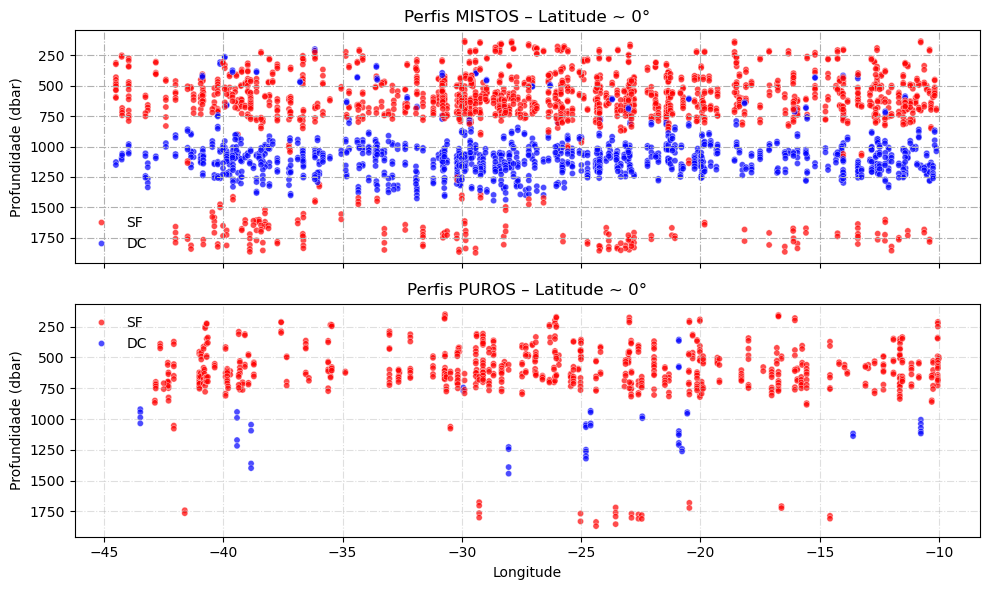

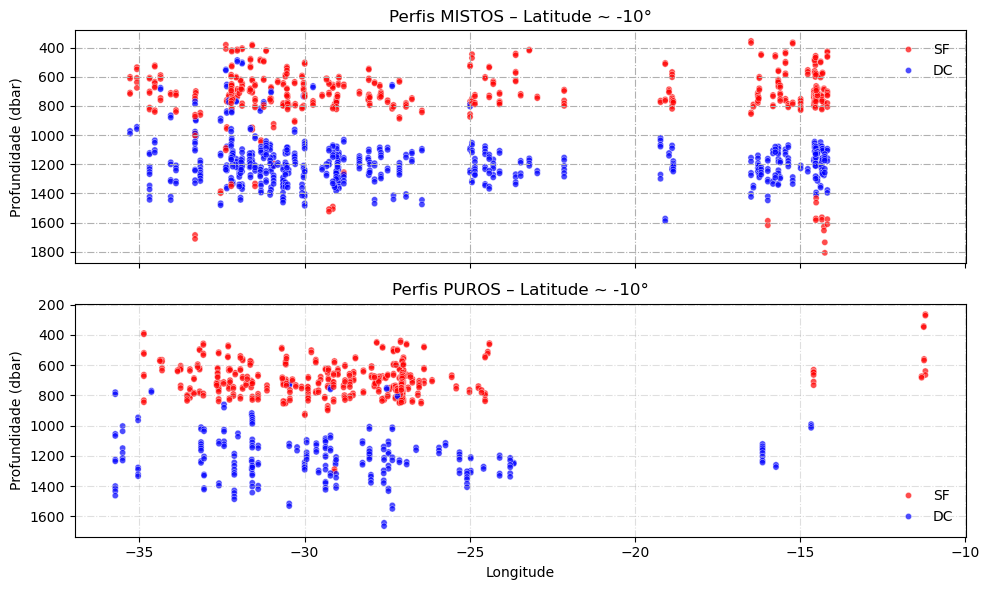

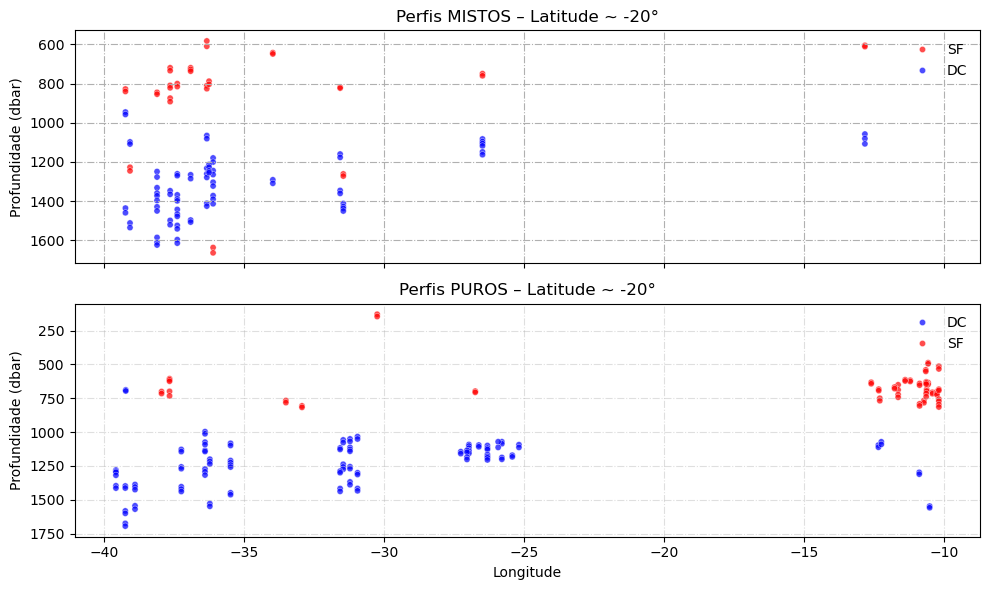

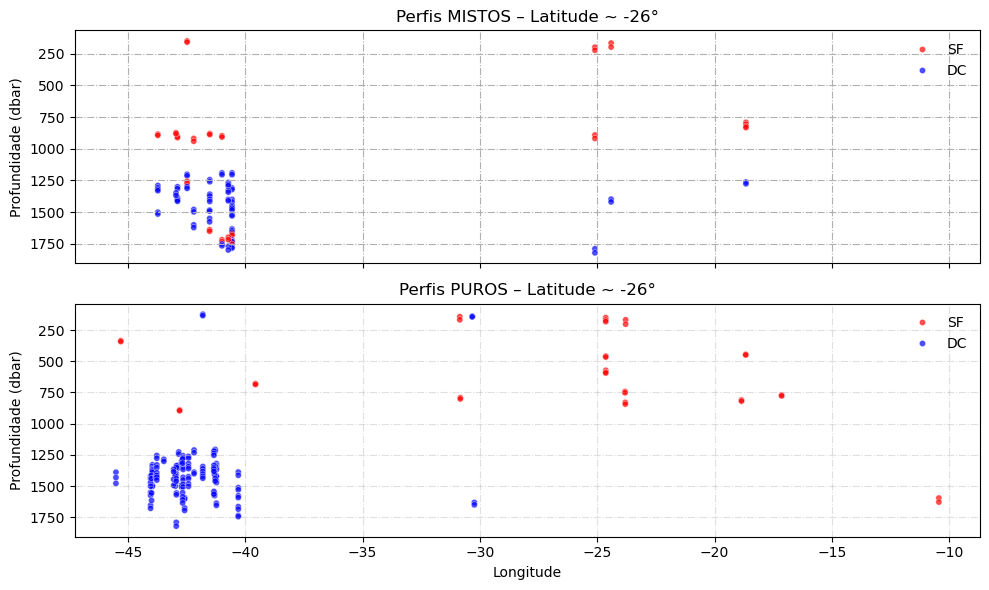

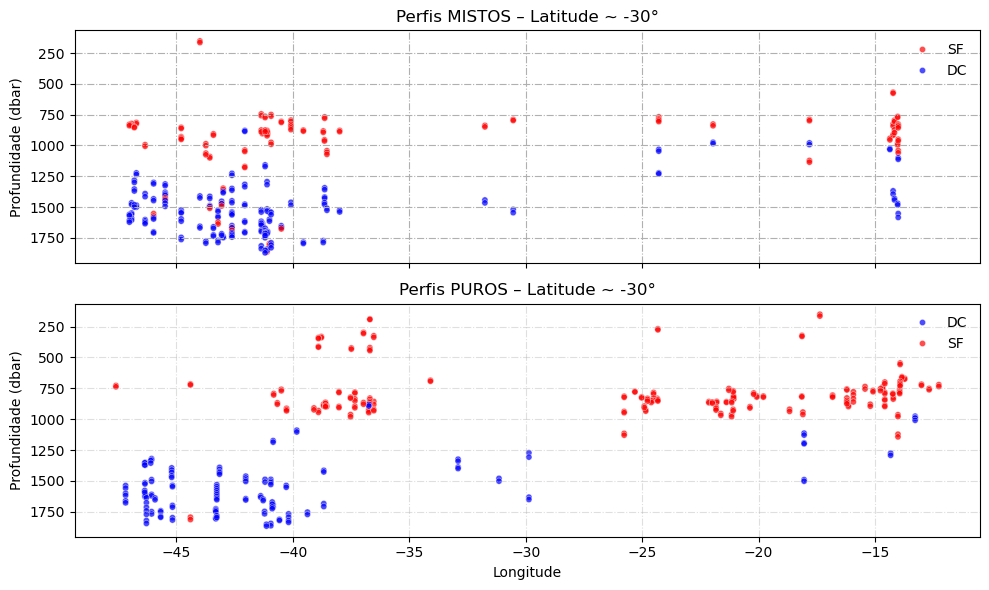

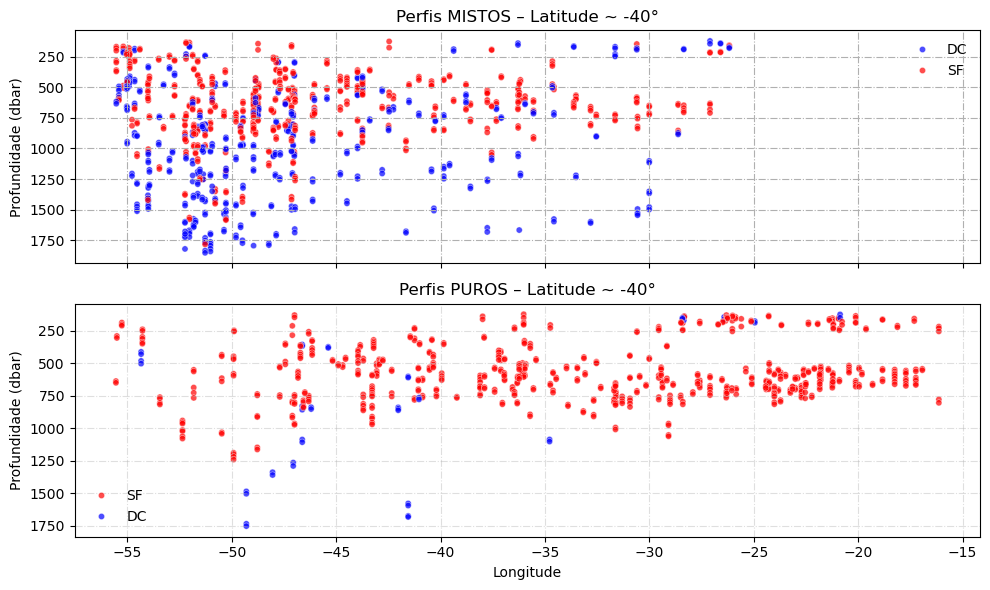

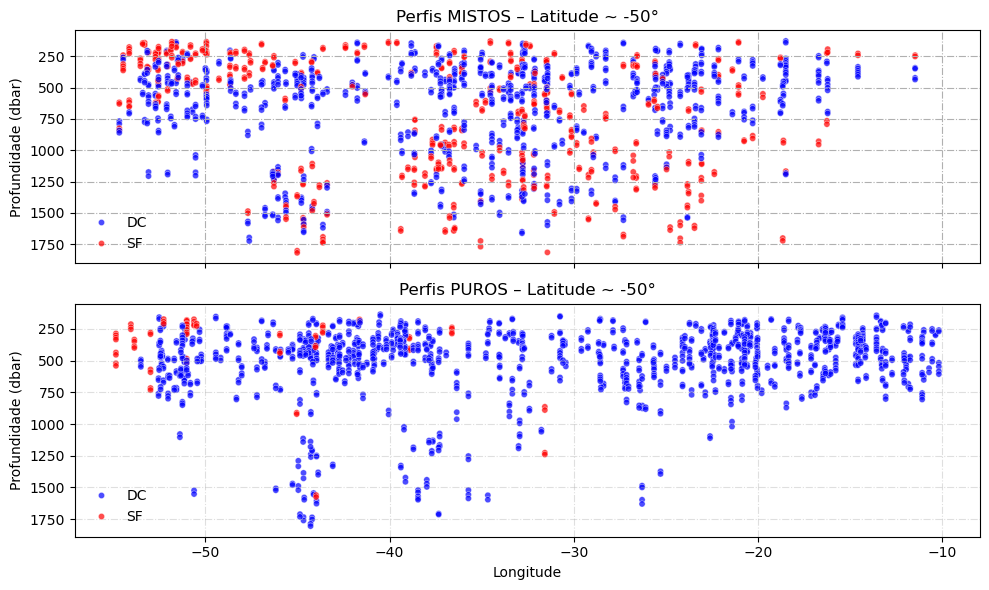

In [5]:
latitudes_interesse = [0, -10, -20, -26, -30, -40, -50]
tol = 0.5  # tolerância em graus

for lat0 in latitudes_interesse:
    
    # Filtra dados próximos da latitude
    misto_lat = df_misto[np.abs(df_misto["lat"] - lat0) <= tol]
    puro_lat  = df_puro[np.abs(df_puro["lat"] - lat0) <= tol]
    
    # Se não houver dados, pula
    if misto_lat.empty and puro_lat.empty:
        print(f"Sem dados para {lat0}°")
        continue
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    #PERFIS MISTOS
    sns.scatterplot(
        data=misto_lat,
        x="lon",
        y="depth",
        hue="regime",
        palette={"DC": "blue", "SF": "red"},
        s=20,
        alpha=0.7,
        ax=axes[0]
    )
    
    axes[0].invert_yaxis()
    axes[0].set_ylabel("Profundidade (dbar)")
    axes[0].set_title(f"Perfis MISTOS – Latitude ~ {lat0}°")
    axes[0].legend(frameon=False)
    axes[0].grid(True, linestyle="-.")
    
    #PERFIS PUROS
    sns.scatterplot(
        data=puro_lat,
        x="lon",
        y="depth",
        hue="regime",
        palette={"DC": "blue", "SF": "red"},
        s=20,
        alpha=0.7,
        ax=axes[1]
    )
    
    axes[1].invert_yaxis()
    axes[1].set_ylabel("Profundidade (dbar)")
    axes[1].set_xlabel("Longitude")
    axes[1].set_title(f"Perfis PUROS – Latitude ~ {lat0}°")
    axes[1].legend(frameon=False)
    axes[1].grid(True, linestyle="-.", alpha=0.4)
    
    plt.tight_layout()
    plt.show()